In [1]:
import pytensor
# Tell PyTensor to use a more robust (but slower) backend that avoids C compilation issues.
# Place this in the first cell of your notebook.
pytensor.config.optimizer = 'fast_compile'

import pandas as pd
import numpy as np
import pymc as pm
import scipy.stats as stats
import arviz as az
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, minmax_scale

from gurobipy import *
import pytensor.tensor as pt

import joblib



WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


## Get player details


In [18]:
# %run '../FPL predictors/Fantasy Go/map FGo to FPL.ipynb'

In [19]:
# # Thresholds
# min_xP = {
#     'GK': 0.3,
#     'DEF': 0.5,
#     'MID': 1.0,
#     'FWD': 1.0
# }

# max_value = {
#     'GK': 5.0,
#     'DEF': 6.0,
#     'MID': 9.0,
#     'FWD': 10.5
# }

# eff_threshold = {
#     'GK': 0.55,
#     'DEF': 0.45,
#     'MID': 0.30,
#     'FWD': 0.30
# }

# eff_threshold = players_preds.groupby('position')['efficiency'].quantile(0.30)


# filtered_players = players_preds[
#     players_preds['efficiency'] >= players_preds['position'].map(eff_threshold)
# ]


# print(filtered_players[filtered_players['position'] == 'GK'].shape, players_preds[players_preds['position'] == 'GK'].shape)
# print(filtered_players[filtered_players['position'] == 'DEF'].shape, players_preds[players_preds['position'] == 'DEF'].shape)
# print(filtered_players[filtered_players['position'] == 'MID'].shape, players_preds[players_preds['position'] == 'MID'].shape)
# print(filtered_players[filtered_players['position'] == 'FWD'].shape, players_preds[players_preds['position'] == 'FWD'].shape)

In [20]:
players_preds = pd.read_csv('./../FPL predictors/with new features/models/preds/players_preds_36.csv', index_col=0)
players_preds['efficiency'] = players_preds['xP_preds'] / players_preds['value']

# Filter to work with only a limited number of players with good xP_pred:value
eff_threshold = players_preds.groupby('position')['efficiency'].quantile(0.30)
filtered_players = players_preds[
    players_preds['efficiency'] >= players_preds['position'].map(eff_threshold)
]

optimizer_pool = filtered_players.copy()


fpl_teams_ids = pd.read_csv('../FPL predictors/with new features/data/fpl_names_24_25.csv')

optimizer_pool = optimizer_pool.rename(columns={'FPL_Name': 'fpl_name', 'Understat_Name': 'understat_name'})
# Add fpl_id to player_preds
optimizer_pool = optimizer_pool.merge(fpl_teams_ids, left_on='fpl_name', right_on='FPL_Name', how='left')
optimizer_pool.dropna(subset=['FPL_ID'], inplace=True)

optimizer_pool = optimizer_pool.drop(['event', 'understat_name', 'fpl_name', 'FPL_ID','FPL_Name', 'team', 'xG_preds', 'xA_preds', 'cs_preds', 'y_preds', 'saves_preds', 'xgc_preds', 'h_team', 'a_team','was_home', 'assists_x'], axis=1)
player_cols = optimizer_pool.columns.tolist()

In [ ]:
data_cols_all = ['clean_sheets',  'creativity', 'ict_index',  'influence',  'selected',  'threat',  'transfers_balance', 'transfers_in',  'transfers_out',  'value',
                 'team_h_difficulty',  'team_a_difficulty', 'ownership_change',  'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

            'clean_sheets_1',  'expected_assists_1',  'expected_goal_involvements_1',
            'expected_goals_1',  'expected_goals_conceded_1',  'goals_conceded_1',  'goals_scored_1',  'ict_index_1',  'influence_1',
            'creativity_1',  'threat_1',  'minutes_1',  'own_goals_1',  'penalties_missed_1',  'penalties_saved_1',  'red_cards_1',
            'yellow_cards_1',  'saves_1',  'starts_1',  'team_a_score_1',  'team_h_score_1',  'total_points_1',  'goals_1',  'shots_1',
            'xG_1',  'xA_1',  'assists_x_1',  'key_passes_1',  'npg_1',  'npxG_1',  'xGChain_1',  'xGBuildup_1',  'xP_1',

            'clean_sheets_3',  'expected_assists_3',  'expected_goal_involvements_3',  'expected_goals_3',  'expected_goals_conceded_3',
            'goals_conceded_3',  'goals_scored_3',  'ict_index_3',  'influence_3',  'creativity_3',  'threat_3',  'minutes_3',  'own_goals_3',
            'penalties_missed_3',  'penalties_saved_3',  'red_cards_3',  'yellow_cards_3',  'saves_3',  'starts_3',  'team_a_score_3',
            'team_h_score_3',  'total_points_3',  'goals_3',  'shots_3',  'xG_3',  'xA_3',  'assists_x_3', 'key_passes_3',
            'npg_3',  'npxG_3',  'xGChain_3',  'xGBuildup_3',  'xP_3',

            'clean_sheets_5',  'expected_assists_5',  'expected_goal_involvements_5',  'expected_goals_5',  'expected_goals_conceded_5',  'goals_conceded_5',
            'goals_scored_5',  'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',  'penalties_missed_5',  'penalties_saved_5',
            'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5',  'total_points_5',  'goals_5',  'shots_5',  'xG_5',  'xA_5',
            'assists_x_5', 'key_passes_5',  'npg_5',  'npxG_5',  'xGChain_5',  'xGBuildup_5',  'xP_5', 'xP_cost'
        ]

data_cols_gk = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh',  'whd',  'wha', 'xP','ownership_percent',

                'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1',
                'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'goals_1', 'xG_1',
                'key_passes_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3',
                'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'key_passes_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_goals_conceded_5',  'goals_conceded_5', 'ict_index_5',  'influence_5',  'creativity_5',  'threat_5',  'minutes_5',  'own_goals_5',
                'penalties_saved_5', 'red_cards_5',  'yellow_cards_5',  'saves_5',  'starts_5',  'team_a_score_5',  'team_h_score_5', 'total_points_5',  'goals_5',  'shots_5',
                'key_passes_5', 'xGChain_5',  'xGBuildup_5', 'xP_5', 'xP_cost'
                ]

data_cols = [
                'clean_sheets', 'creativity', 'ict_index', 'influence', 'selected', 'threat', 'transfers_balance', 'transfers_in', 'transfers_out', 'value',
                'team_h_difficulty',  'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'whh', 'whd', 'wha', 'xP', 'ownership_percent',

                'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1',
                'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
                'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'key_passes_1', 'npg_1', 'npxG_1',
                'xGChain_1', 'xGBuildup_1', 'xP_1',

                'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3',
                'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
                'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'key_passes_3', 'npg_3', 'npxG_3',
                'xGChain_3', 'xGBuildup_3', 'xP_3',

                'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5',
                'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
                'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'key_passes_5', 'npg_5', 'npxG_5',
                'xGChain_5', 'xGBuildup_5', 'xP_5', 'xP_cost'
        ]

feats_cols = ["selected", "transfers_in", "transfers_out", "value", "xP_5", "total_points_1", "team_h_difficulty", "team_a_difficulty", "ownership_percent"]


feats_cols_gk = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5', 'expected_goals_conceded_5', 'saves_5',

                 'opponent_ict', 'opponent_xG',  'opponent_xA','opponent_goals_scored', 'opponent_shots', 'opponent_npxG','opponent_value','opponent_whh',
                   'opponent_whd', 'opponent_wha', 'opponent_goals_scored_3',  'opponent_goals_scored_5'
                ]

feats_cols_def = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5', 'expected_goals_conceded_5', 'xG_5', 'xA_5',

                'opponent_ict', 'opponent_xG',  'opponent_xA','opponent_goals_scored', 'opponent_shots', 'opponent_npxG','opponent_value','opponent_whh',
                'opponent_whd', 'opponent_wha', 'opponent_goals_scored_3',  'opponent_goals_scored_5'
                ]

feats_cols_mid = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5','npxG_5',

                 'opponent_ict','opponent_value','opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_xgc_3', 'opponent_xgc_5','opponent_gc_3', 'opponent_gc_5',
                ]

feats_cols_fwd = [
                'ownership_percent', 'transfers_in', 'transfers_out', 'value', 'team_h_difficulty', 'team_a_difficulty',
                 'total_points_1', 'minutes_5','npxG_5',

                 'opponent_ict', 'opponent_value','opponent_whh', 'opponent_whd', 'opponent_wha', 'opponent_xgc_3', 'opponent_xgc_5','opponent_gc_3', 'opponent_gc_5'
                ]

FPL_teams_23_24 = ['West Ham United', 'Manchester United', 'Everton', 'Bournemouth',
       'Brighton and Hove Albion', 'Crystal Palace', 'Fulham', 'Luton',
       'Tottenham Hotspur', 'Newcastle United', 'Aston Villa',
       'Liverpool', 'Chelsea', 'Sheffield United', 'Nottingham Forest',
       'Burnley', 'Arsenal', 'Manchester City', 'Wolverhampton Wanderers',
       'Brentford']

In [22]:
gw=35
data_23_24 = pd.read_csv('../FPL predictors/Fantasy Go/fantasyGo_FPL.csv') #.dropna()

data_23_24 = data_23_24[data_23_24['player_team'].isin(FPL_teams_23_24)]

data_23_24['xP_cost'] = round(data_23_24['xP']/data_23_24['value'], 2)



In [23]:

data_23_24['gw'] = data_23_24['round']
data_23_24['team'] = data_23_24['player_team']
data_23_24['opponent_team'] = data_23_24.apply(lambda row: row['a_team'] if row['was_home'] == 1 else row['h_team'], axis=1)
data_23_24[['h_team', 'a_team', 'was_home', 'team', 'opponent_team', 'player_team', 'gw', 'round']]


sum_features = [
    'creativity', 'influence', 'threat',
    'expected_goals_1', 'expected_assists_1', 'expected_goal_involvements_1',
    'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1',
    'shots_1', 'key_passes_1', 'npg_1', 'npxG_1',
]

mean_features = [
    'value', 'ict_index', 'selected', 'transfers_in', 'transfers_out'
]

# max_features = [
#     'minutes_1', 'influence'
# ]

identity_features = [
    'whh', 'whd', 'wha',    # bookmaker odds
    'was_home',
    'opponent_team'
]


In [24]:
team_df = data_23_24.groupby(['team', 'gw']).agg({
    **{f: 'sum' for f in sum_features},
    **{f: 'mean' for f in mean_features},
    # **{f: 'max' for f in max_features},
    **{f: 'first' for f in identity_features}
}).reset_index()

for col in ['expected_goals_conceded_1','goals_conceded_1','goals_scored_1']:
    team_df[f'{col}_3'] = team_df.groupby('team')[col].rolling(3, min_periods=1).mean().reset_index(0, drop=True)
    team_df[f'{col}_5'] = team_df.groupby('team')[col].rolling(5, min_periods=1).mean().reset_index(0, drop=True)


team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

team_df = team_df.rename(columns={
    'creativity': 'team_creativity',
    'influence': 'team_influence',
    'threat': 'team_threat',
    'expected_goals_1': 'team_expected_goals',
    'expected_assists_1': 'team_expected_assists',
    'expected_goal_involvements_1': 'team_expected_goal_involvements',
    'expected_goals_conceded_1': 'team_expected_goals_conceded',
    'goals_conceded_1': 'team_goals_conceded',
    'goals_scored_1': 'team_goals_scored',
    'shots_1': 'team_shots',
    'attempted_passes_1': 'team_attempted_passes',
    'key_passes_1': 'team_key_passes',
    'npg_1': 'team_npg',
    'npxG_1': 'team_npxG',
    'value': 'team_value',
    'ict_index': 'team_ict_index',
    'selected': 'team_selected',
    'transfers_in': 'team_transfers_in',
    'transfers_out': 'team_transfers_out',
    'whh': 'team_whh',
    'whd': 'team_whd',
    'wha': 'team_wha',
    'was_home': 'team_was_home',
    'expected_goals_conceded_1_3': 'team_expected_goals_conceded_3',
    'expected_goals_conceded_1_5': 'team_expected_goals_conceded_5',
    'goals_conceded_1_3': 'team_goals_conceded_3',
    'goals_conceded_1_5': 'team_goals_conceded_5',
    'goals_scored_1_3': 'team_goals_scored_3',
    'goals_scored_1_5': 'team_goals_scored_5',

    })

opponent_stats = team_df[['team', 'gw','team_ict_index', 'team_expected_goals', 'team_expected_assists', 'team_goals_scored', 'team_shots', 'team_npxG', 'team_value',
                          'team_whh', 'team_whd', 'team_wha', 'team_expected_goals_conceded_3', 'team_expected_goals_conceded_5', 'team_goals_conceded_3', 'team_goals_conceded_5',
                          'team_goals_scored_3', 'team_goals_scored_5']].rename(

                columns={'team': 'opponent_team', 'team_ict_index':'opponent_ict','team_expected_goals': 'opponent_xG', 'team_expected_assists': 'opponent_xA',
                        'team_goals_scored': 'opponent_goals_scored', 'team_shots': 'opponent_shots', 'team_npxG': 'opponent_npxG', 'team_value': 'opponent_value',
                        'team_whh': 'opponent_whh', 'team_whd': 'opponent_whd', 'team_wha': 'opponent_wha', 'team_expected_goals_conceded_3': 'opponent_xgc_3',
                        'team_expected_goals_conceded_5': 'opponent_xgc_5', 'team_goals_conceded_3': 'opponent_gc_3', 'team_goals_conceded_5': 'opponent_gc_5',
                        'team_goals_scored_3': 'opponent_goals_scored_3', 'team_goals_scored_5': 'opponent_goals_scored_5'
                        })

# opponent_stats
# 2. Merge this back into the original dataframe matching on 'opponent_team' and 'gw'
team_df = team_df.merge(opponent_stats, on=['opponent_team', 'gw'], how='left')

data_23_24 = data_23_24.merge(team_df, on=['team', 'gw'], how='left')


In [25]:
data_tar = data_23_24[data_23_24['event']==gw]
data = data_23_24[data_23_24['event'] < gw]

data_24_25_test = data_23_24[data_23_24['event'] > gw]

joblib.dump(data_cols, './data_cols')

# data_ = data[data_cols]
gk_data = data[data['position'] == 'GK'][feats_cols_gk] #[data_cols_gk]
def_data = data[data['position'] == 'DEF'][feats_cols_def]#[data_cols]
mid_data = data[data['position'] == 'MID'][feats_cols_mid]#[data_cols]
fwd_data = data[data['position'] == 'FWD'][feats_cols_fwd]#[data_cols]

# transfers_in_log = np.log(df['transfers_in'] + 1)


# fwd_data
gk_data = gk_data.dropna()
def_data = def_data.dropna()
mid_data = mid_data.dropna()
fwd_data = fwd_data.dropna()

In [26]:
gk_data['transfers_in_log'] = gk_data['transfers_in'].apply(lambda x: np.log(x + 1))

gk_data['transfers_out_log'] = gk_data['transfers_out'].apply(lambda x: np.log(x + 1))
gk_data['selected_log'] = gk_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
gk_data['saves_times_transfers'] = gk_data['saves_5'] * gk_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
gk_data['points1_times_transfers'] = gk_data['total_points_1'] * gk_data['transfers_in_log']

gk_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

gk_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'saves_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,saves_times_transfers,points1_times_transfers
28,10.725577,11.429076,2.290513,2.145115,21.451155
29,10.887287,11.247970,2.636912,6.532372,65.323724
30,10.167235,11.723729,0.000000,8.133788,10.167235
31,10.070442,10.444328,2.239645,10.070442,20.140883
32,9.330875,8.720134,1.593309,11.197050,55.985251
...,...,...,...,...,...
11284,10.378385,9.404920,0.652325,31.135156,20.756771
11285,10.338867,8.536211,2.341806,28.948829,10.338867
11286,9.571993,9.311542,1.960095,24.887182,19.143986
11287,9.685207,9.652780,0.000000,23.244497,58.111243


In [27]:
def_data['transfers_in_log'] = def_data['transfers_in'].apply(lambda x: np.log(x + 1))

def_data['transfers_out_log'] = def_data['transfers_out'].apply(lambda x: np.log(x + 1))
def_data['selected_log'] = def_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
def_data['xa_times_transfers'] = def_data['xA_5'] * def_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
def_data['points1_times_transfers'] = def_data['total_points_1'] * def_data['transfers_in_log']

def_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

def_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'xa_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,xa_times_transfers,points1_times_transfers
8,7.028201,7.050123,0.000000,0.281128,14.056403
9,6.756932,6.933423,0.000000,0.270277,6.756932
10,5.497168,6.426488,0.000000,0.219887,-5.497168
11,5.978886,6.257668,0.398776,0.239155,5.978886
12,8.067776,6.098074,1.289233,0.645422,8.067776
...,...,...,...,...,...
11088,3.891820,3.258097,0.000000,0.233509,7.783641
11118,0.000000,0.000000,0.000000,0.000000,0.000000
11119,0.000000,0.000000,0.000000,0.000000,0.000000
11120,0.000000,0.000000,0.000000,0.000000,0.000000


In [28]:
mid_data['transfers_in_log'] = mid_data['transfers_in'].apply(lambda x: np.log(x + 1))

mid_data['transfers_out_log'] = mid_data['transfers_out'].apply(lambda x: np.log(x + 1))
mid_data['selected_log'] = mid_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
mid_data['npxg_times_transfers'] = mid_data['npxG_5'] * mid_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
mid_data['points1_times_transfers'] = mid_data['total_points_1'] * mid_data['transfers_in_log']

mid_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

mid_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'npxg_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,npxg_times_transfers,points1_times_transfers
34,6.248043,4.941642,0.000000,0.000000,6.248043
35,7.815207,6.135565,0.000000,0.156304,15.630414
36,7.815207,6.135565,0.000000,0.156304,15.630414
37,7.271009,6.995766,0.000000,0.145420,7.271009
38,3.555348,6.775366,0.000000,0.071107,3.555348
...,...,...,...,...,...
11227,5.590987,5.655992,0.000000,0.000000,5.590987
11228,5.231109,5.513429,0.000000,0.000000,10.462217
11229,5.147494,5.690359,0.000000,0.051475,10.294989
11230,5.429346,5.749393,0.593327,0.162880,5.429346


In [29]:
fwd_data['transfers_in_log'] = fwd_data['transfers_in'].apply(lambda x: np.log(x + 1))

fwd_data['transfers_out_log'] = fwd_data['transfers_out'].apply(lambda x: np.log(x + 1))
fwd_data['selected_log'] = fwd_data['ownership_percent'].apply(lambda x: np.log(x + 1))

# xg_times_transfers = xG_5 * transfers_in
fwd_data['npxg_times_transfers'] = fwd_data['npxG_5'] * fwd_data['transfers_in_log']
# points1_times_transfers = total_points_1 * transfers_in
fwd_data['points1_times_transfers'] = fwd_data['total_points_1'] * fwd_data['transfers_in_log']

fwd_data.drop(columns=['transfers_in', 'transfers_out'], inplace=True)

fwd_data[['transfers_in_log', 'transfers_out_log', 'selected_log', 'npxg_times_transfers', 'points1_times_transfers']]

,transfers_in_log,transfers_out_log,selected_log,npxg_times_transfers,points1_times_transfers
1,0.000000,3.970292,0.0,0.000000,0.000000
2,0.000000,2.397895,0.0,0.000000,0.000000
3,0.000000,1.386294,0.0,0.000000,0.000000
265,6.514713,6.298949,0.0,0.000000,0.000000
266,6.095825,6.040255,0.0,0.000000,6.095825
...,...,...,...,...,...
11262,7.651596,8.339740,0.0,1.071223,7.651596
11263,8.403352,7.355002,0.0,0.672268,8.403352
11264,6.922644,8.120291,0.0,0.623038,0.000000
11265,6.049733,7.376508,0.0,0.120995,6.049733


In [30]:


gk_data = gk_data.select_dtypes(include=[np.number])
gk_data = gk_data.dropna()
gk_data = pd.DataFrame(minmax_scale(gk_data), columns=gk_data.columns, index=gk_data.index)

def_data = def_data.select_dtypes(include=[np.number])
def_data = def_data.dropna()
def_data = pd.DataFrame(minmax_scale(def_data), columns=def_data.columns, index=def_data.index)

mid_data = mid_data.select_dtypes(include=[np.number])
mid_data = mid_data.dropna()
mid_data = pd.DataFrame(minmax_scale(mid_data), columns=mid_data.columns, index=mid_data.index)

fwd_data = fwd_data.select_dtypes(include=[np.number])
fwd_data = fwd_data.dropna()
fwd_data = pd.DataFrame(minmax_scale(fwd_data), columns=fwd_data.columns, index=fwd_data.index)

# Selection percentages
gk_select_by = gk_data['ownership_percent']
def_select_by = def_data['ownership_percent']
mid_select_by = mid_data['ownership_percent']
fwd_select_by = fwd_data['ownership_percent']


# Normalise the select_percts to get the working probs
gk_probs = gk_select_by/np.sum(gk_select_by)
def_probs = def_select_by/np.sum(def_select_by)
mid_probs = mid_select_by/np.sum(mid_select_by)
fwd_probs = fwd_select_by/np.sum(fwd_select_by)

# 1. Define a small constant (epsilon) to replace the zeros
epsilon = 1e-9 # A very small number

# 2. Replace all zeros with this small number
gk_probs[gk_probs == 0] = epsilon
def_probs[def_probs == 0] = epsilon
mid_probs[mid_probs == 0] = epsilon
fwd_probs[fwd_probs == 0] = epsilon

gk_data = gk_data.drop(columns='ownership_percent')
def_data = def_data.drop(columns='ownership_percent')
mid_data = mid_data.drop(columns='ownership_percent')
fwd_data = fwd_data.drop(columns='ownership_percent')

In [31]:
# 1. Standardize (PCA works best on standardized data)
scaler_gk = StandardScaler(with_mean=True, with_std=True)
scaler_def = StandardScaler(with_mean=True, with_std=True)
scaler_mid = StandardScaler(with_mean=True, with_std=True)
scaler_fwd = StandardScaler(with_mean=True, with_std=True)

# print(gk_data.shape)
X_gk = pd.DataFrame(scaler_gk.fit_transform(gk_data.values), columns=gk_data.columns)
X_def = pd.DataFrame(scaler_def.fit_transform(def_data.values), columns=def_data.columns)
X_mid = pd.DataFrame(scaler_mid.fit_transform(mid_data.values), columns=mid_data.columns)
X_fwd = pd.DataFrame(scaler_fwd.fit_transform(fwd_data.values), columns=fwd_data.columns)

# save standardscaler model
joblib.dump(scaler_gk, "scaler_gk.pkl")
joblib.dump(scaler_def, "scaler_def.pkl")
joblib.dump(scaler_mid, "scaler_mid.pkl")
joblib.dump(scaler_fwd, "scaler_fwd.pkl")


# 2. Choose # of components or variance threshold
pca_gk = PCA(n_components=0.95)  # 0.95 = keep enough PCs to explain 95% of variance
pca_def = PCA(n_components=0.95)
pca_mid = PCA(n_components=0.95)
pca_fwd = PCA(n_components=0.95)

# 3. Fit PCA and transform
X_gk_pca = pd.DataFrame(pca_gk.fit_transform(X_gk))
X_def_pca = pd.DataFrame(pca_def.fit_transform(X_def))
X_mid_pca = pd.DataFrame(pca_mid.fit_transform(X_mid))
X_fwd_pca = pd.DataFrame(pca_fwd.fit_transform(X_fwd))

# save pca mode;
joblib.dump(pca_gk, "pca_gk.pkl")
joblib.dump(pca_def, "pca_def.pkl")
joblib.dump(pca_mid, "pca_mid.pkl")
joblib.dump(pca_fwd, "pca_fwd.pkl")

print("Original shape:", X_gk.shape, X_def.shape, X_mid.shape, X_fwd.shape)
print("Reduced shape:", X_gk_pca.shape, X_def_pca.shape, X_mid_pca.shape, X_fwd_pca.shape)
# X_gk

Original shape: (612, 24) (3209, 25) (4337, 20) (1154, 20)
Reduced shape: (612, 14) (3209, 16) (4337, 12) (1154, 13)


In [32]:
explained_variance = pca_def.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("Explained variance per component:")
print(explained_variance)

print("\nCumulative explained variance:")
print(cumulative_variance)

# Build the table
pca_table = pd.DataFrame({
    'PC': range(1, len(explained_variance) + 1),
    'Explained Variance (%)': explained_variance * 100,
    'Cumulative Variance (%)': cumulative_variance * 100
})

pca_table


Explained variance per component:
[0.21177719 0.17168382 0.1072981  0.07086906 0.06341994 0.05768178
 0.04960373 0.04180932 0.03861441 0.03147178 0.02567408 0.02299529
 0.01990568 0.01717889 0.0140859  0.01248586]

Cumulative explained variance:
[0.21177719 0.38346101 0.49075911 0.56162817 0.62504811 0.68272989
 0.73233362 0.77414294 0.81275736 0.84422913 0.86990321 0.8928985
 0.91280417 0.92998306 0.94406897 0.95655483]


,PC,Explained Variance (%),Cumulative Variance (%)
0,1,21.177719,21.177719
1,2,17.168382,38.346101
2,3,10.729810,49.075911
3,4,7.086906,56.162817
4,5,6.341994,62.504811
5,6,5.768178,68.272989
6,7,4.960373,73.233362
7,8,4.180932,77.414294
8,9,3.861441,81.275736
9,10,3.147178,84.422913


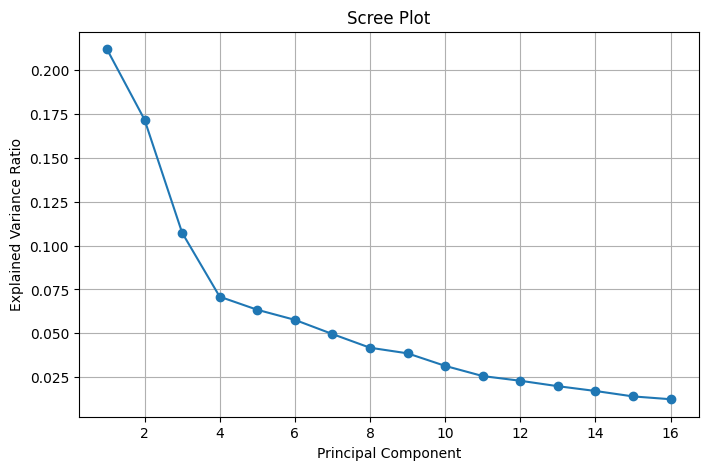

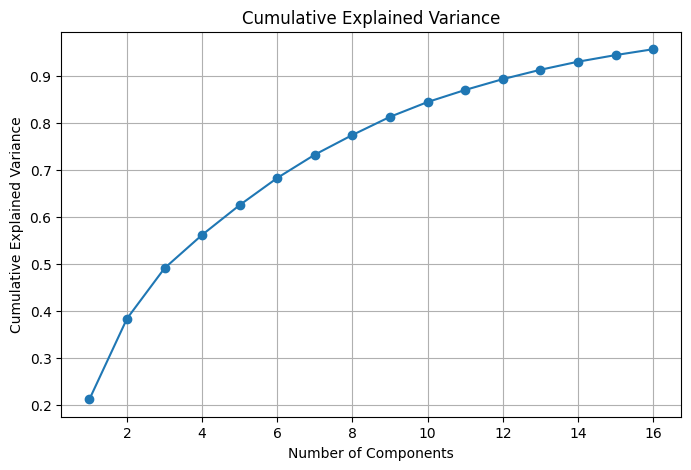

In [33]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.grid(True)
plt.show()

# Optional cumulative plot
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()


## Generate Betas


In [48]:
def fit_dirichlet_regression(X, P_observed):
    """
    Fits a Bayesian Dirichlet regression model using PyMC to estimate beta coefficients.


    Args:
        X (np.ndarray): The feature matrix for a specific position (e.g., GKs).
                        Shape should be (num_players, num_features).
        P_observed (np.ndarray): The observed historical ownership proportions for that position.
                                 Shape should be (num_players,). Must sum to 1.

    Returns:
        pm.backends.base.MultiTrace: The results of the MCMC simulation, containing posterior samples for beta.
    """
    n_players, n_features = X.shape

    with pm.Model() as dirichlet_model:
        # 1. Define priors for our beta coefficients. We'll use a flat (uninformative) prior as mentioned.
        # [span_0](start_span)This corresponds to p(beta) in equation (6)[span_0](end_span).
        # betas = pm.Uniform("betas", lower=-5, upper=5, shape=(n_features,)) #
        betas = pm.Normal("betas", mu=0, sigma=1, shape=(n_features,))

        # 2. Calculate alpha based on the linear model: alpha = exp(X * beta)
        # [span_1](start_span)This is equation (4) in the paper[span_1](end_span).
        alpha = pm.math.exp(pm.math.dot(X, betas)) + 1e-6

        # 3. Define the likelihood of our observed data P_observed
        # The observed ownership proportions are assumed to follow a Dirichlet distribution
        # parameterized by alpha. [span_2](start_span)[span_3](start_span)This is the core of the regression[span_2](end_span)[span_3](end_span).
        pm.Dirichlet('p_obs', a=alpha, observed=P_observed)

        # 4. Run the MCMC sampler to get the posterior distribution of beta
        # print("Fitting Dirichlet regression model with PyMC...")
        # trace = pm.sample(3000, tune=1000, chains=4, cores=4)
        # print("✅ Model fitting complete.")

        approx = pm.fit(n=2000, method='advi', progressbar=True)
        trace = approx.sample(2000)

    return trace

Output()

Finished [100%]: Average Loss = 1.3138e+09
arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],0.09,0.63,-1.02,1.33,0.02,0.01,1776.55,1567.49,NaN
betas[1],-0.06,0.64,-1.26,1.16,0.02,0.01,1769.50,1833.78,NaN
betas[2],-0.03,0.60,-1.07,1.13,0.01,0.01,1971.49,1854.84,NaN
betas[3],0.09,0.63,-1.08,1.21,0.02,0.01,1635.82,1962.90,NaN
betas[4],0.05,0.64,-1.17,1.18,0.01,0.01,1892.82,1995.81,NaN
betas[5],0.03,0.66,-1.17,1.26,0.01,0.01,1992.99,1867.42,NaN
betas[6],0.01,0.64,-1.20,1.18,0.01,0.01,1981.93,1970.60,NaN
betas[7],-0.08,0.62,-1.31,0.99,0.01,0.01,2042.22,1702.22,NaN
betas[8],-0.10,0.62,-1.27,1.02,0.01,0.01,2006.42,1744.19,NaN
betas[9],-0.14,0.64,-1.37,1.04,0.01,0.01,1984.57,1899.60,NaN


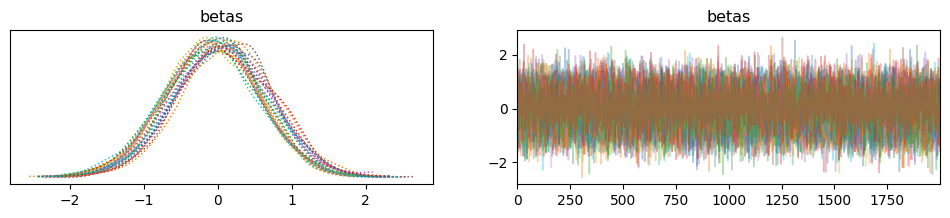

In [49]:
# Fit the model to get beta estimates
trace_gk = fit_dirichlet_regression(X_gk, gk_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_gk = trace_gk.posterior['betas'].mean(axis=(0,1)).values

# trace_gk
az.plot_trace(trace_gk, combined=True)

# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_gk, var_names=["betas"], round_to=2)
summary

Output()

Finished [100%]: Average Loss = 3.7808e+12


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

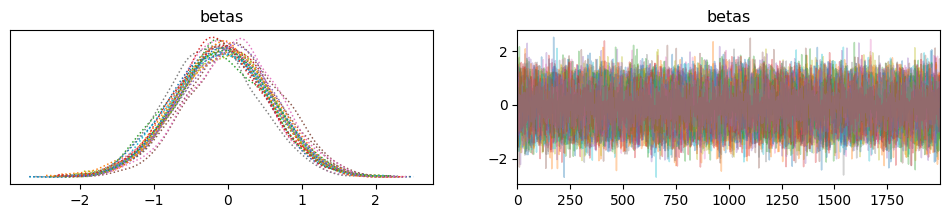

In [50]:
# Fit the model to get beta estimates
trace_def = fit_dirichlet_regression(X_def, def_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_def = trace_def.posterior['betas'].mean(axis=(0,1)).values

trace_def
az.plot_trace(trace_def, combined=True)

Output()

Finished [100%]: Average Loss = 1.678e+11


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

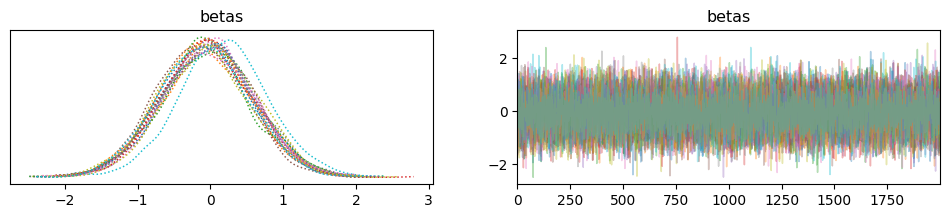

In [51]:
# Fit the model to get beta estimates
trace_mid = fit_dirichlet_regression(X_mid, mid_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_mid = trace_mid.posterior['betas'].mean(axis=(0,1)).values

trace_mid
az.plot_trace(trace_mid, combined=True)

Output()

Finished [100%]: Average Loss = 3.3952e+07


array([[<Axes: title={'center': 'betas'}>,
        <Axes: title={'center': 'betas'}>]], dtype=object)

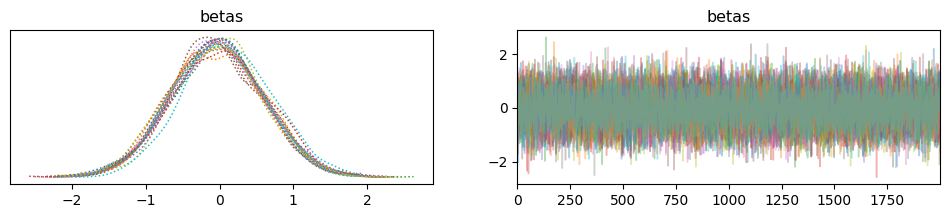

In [52]:
# Fit the model to get beta estimates
trace_fwd = fit_dirichlet_regression(X_fwd, fwd_probs)

# Extract the mean of the beta posterior samples to use in Algorithm 1
beta_estimates_fwd = trace_fwd.posterior['betas'].mean(axis=(0,1)).values

trace_fwd
az.plot_trace(trace_fwd, combined=True)

In [53]:
# Summary with R-hat, ESS, mean, sd, etc.
summary = az.summary(trace_fwd, var_names=["betas"], round_to=2)
summary

arviz - WARNING - Shape validation failed: input_shape: (1, 2000), minimum_shape: (chains=2, draws=4)


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
betas[0],-0.06,0.61,-1.25,1.01,0.01,0.01,1910.55,1849.96,NaN
betas[1],-0.07,0.63,-1.22,1.16,0.01,0.01,1951.34,1720.76,NaN
betas[2],-0.04,0.61,-1.15,1.10,0.01,0.01,2040.57,1961.53,NaN
betas[3],-0.03,0.62,-1.13,1.12,0.01,0.01,1930.85,1722.28,NaN
betas[4],-0.02,0.62,-1.17,1.18,0.01,0.01,1986.50,1782.75,NaN
betas[5],-0.07,0.63,-1.27,1.07,0.01,0.01,1983.27,1863.20,NaN
betas[6],-0.07,0.61,-1.23,1.03,0.01,0.01,1770.41,1799.17,NaN
betas[7],-0.04,0.62,-1.17,1.12,0.01,0.01,2173.76,2002.87,NaN
betas[8],0.02,0.61,-1.06,1.19,0.01,0.01,1697.74,2001.23,NaN
betas[9],0.11,0.61,-1.08,1.20,0.01,0.01,2245.35,1875.07,NaN


In [54]:
joblib.dump(trace_gk, './trace_gk')
joblib.dump(trace_def, './trace_def')
joblib.dump(trace_mid, './trace_mid')
joblib.dump(trace_fwd, './trace_fwd')

['./trace_fwd']

In [55]:
beta_estimates_fwd

array([-0.05654388, -0.07148381, -0.04205079, -0.0299896 , -0.0164226 ,
       -0.06778809, -0.07154965, -0.03644803,  0.01595761,  0.1131463 ,
       -0.04745344, -0.03236354, -0.01818176,  0.00447698,  0.00838767,
       -0.06258739, -0.03111629, -0.01002453, -0.07725307, -0.04526824])

In [56]:
 # Convert to pandas DataFrame
pd.DataFrame({
    "gk": beta_estimates_gk
}).to_csv('./gk_beta_1.csv', index=False)

pd.DataFrame({
    "def": beta_estimates_def
}).to_csv('./def_beta_1.csv', index=False)

pd.DataFrame({
    "mid": beta_estimates_mid
}).to_csv('./mid_beta_1.csv', index=False)

pd.DataFrame({
    "fwd": beta_estimates_fwd
}).to_csv('./fwd_beta_1.csv', index=False)